In [26]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime
import IPython.display as display
from PIL import Image
import io
import time

Width: 1364px
Height: 768px
FPS: 25.00
Frame Count: 1549
Duration: 61.96 seconds


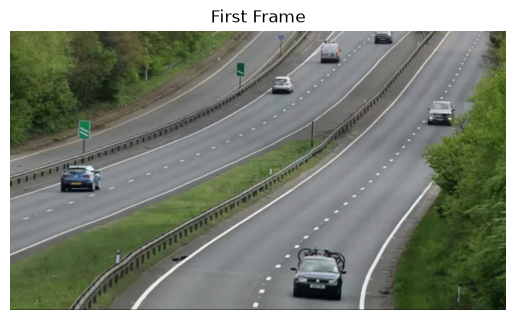

In [4]:
video_path = r"C:\Users\PC-LAB1\img_processing_lab\videos\british_highway_traffic.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open the video")
else:
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = frame_count / fps if fps > 0 else 0

print(f"Width: {width}px")
print(f"Height: {height}px")
print(f"FPS: {fps:.2f}")
print(f"Frame Count: {frame_count}")
print(f"Duration: {duration:.2f} seconds")

ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
    plt.imshow(frame_rgb)
    plt.axis('off')  # Hide axis ticks
    plt.title("First Frame")
    plt.show()
else:
    print("Error: Could not read the first frame.")

cap.release()


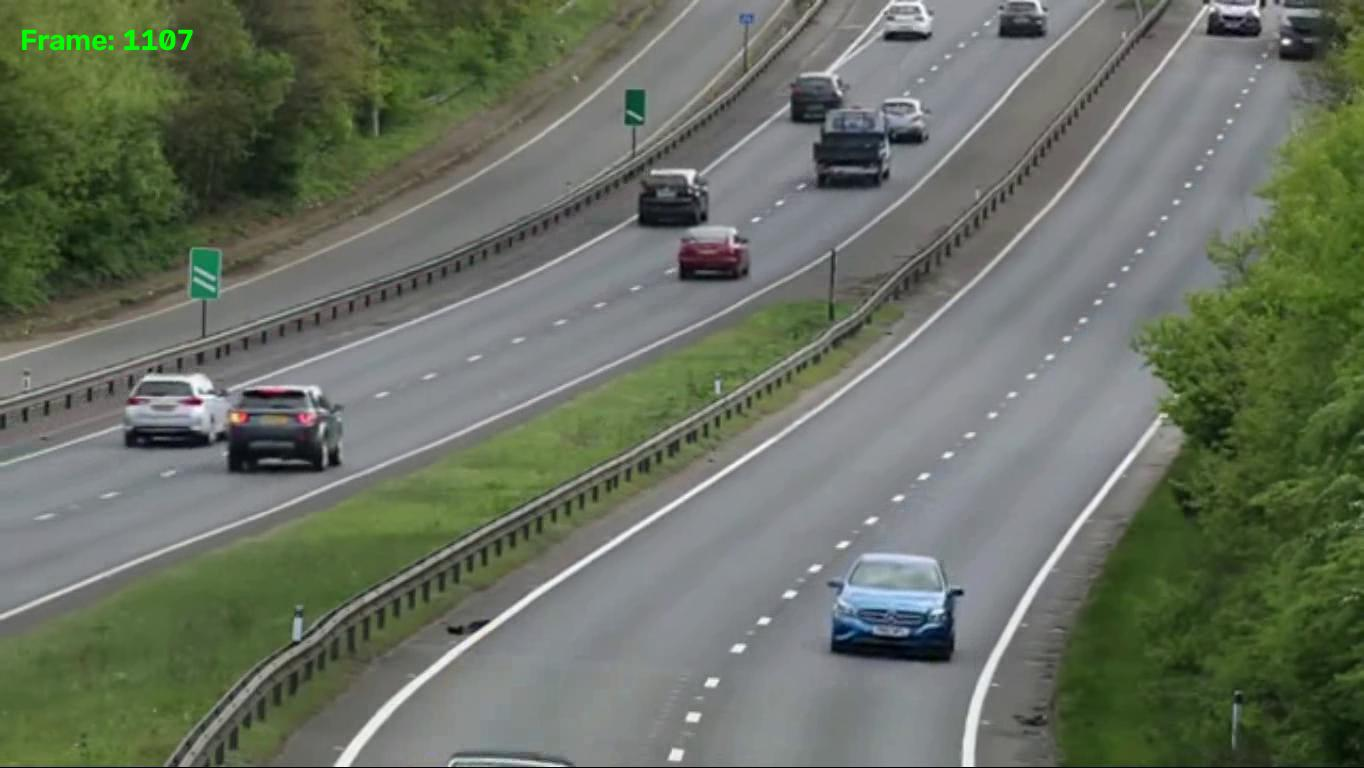

Stream stopped manually.


In [7]:
video_path = r"C:\Users\PC-LAB1\img_processing_lab\videos\british_highway_traffic.mp4"
cap = cv2.VideoCapture(video_path)
d = display.display(display.Image(data=b""), display_id=True)

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame_number = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
        cv2.putText(
            frame,
            f"Frame: {frame_number}",
            (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2,
        )

        # Convert BGR to RGB and encode to JPEG bytes
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_img = Image.fromarray(frame_rgb)
        buf = io.BytesIO()
        pil_img.save(buf, format="JPEG")

        # Update display in cell output
        d.update(display.Image(data=buf.getvalue()))

except KeyboardInterrupt:
    print("Stream stopped manually.")

cap.release()

In [11]:
video_path = r"C:\Users\PC-LAB1\img_processing_lab\videos\british_highway_traffic.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Reached end of video or stream error.")
            break

        # Get current frame number (1-based index or 0-based index)
        frame_number = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

        # Overlay current frame number on the image text layer
        cv2.putText(
            frame,
            f"Frame: {frame_number}",
            (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

        cv2.imshow("Real-Time Video Reader", frame)

        # cv2.waitKey(25) delays 25ms (~40 FPS playback speed)
        # Mask with 0xFF to get ASCII value of keypress
        key = cv2.waitKey(25) & 0xFF
        if key == 27 or key == ord("q"):  # 27 is ASCII for ESC
            print(f"Stopped manually at frame {frame_number}.")
            break

cap.release()
cv2.destroyAllWindows()

Stopped manually at frame 84.


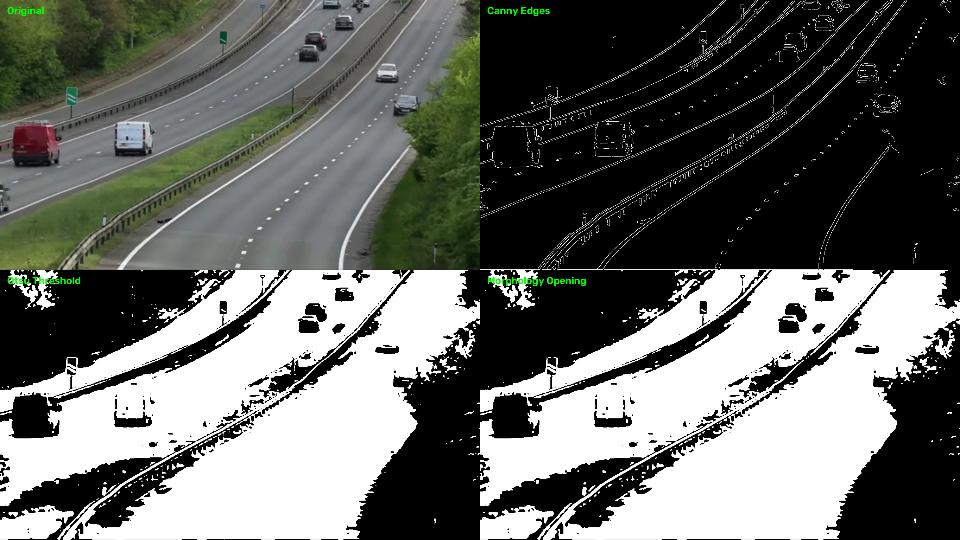

End of video stream.


In [13]:
video_path = r"C:\Users\PC-LAB1\img_processing_lab\videos\british_highway_traffic.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    # Initialize IPython Display block
    d = display.display(display.Image(data=b""), display_id=True)
    kernel = np.ones((3, 3), np.uint8)

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # 1. Grayscale Conversion
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # 2. Gaussian Blur
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)

            # 3. Canny Edge Detection
            canny = cv2.Canny(blurred, 50, 150)

            # 4. Otsu Thresholding
            _, thresh_otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

            # 5. Morphological Opening (Remove Noise)
            opening = cv2.morphologyEx(thresh_otsu, cv2.MORPH_OPEN, kernel)

            # --- PREPARE FOR DISPLAY (Combine 4 streams into a 2x2 grid) ---
            
            # Convert single-channel grayscale maps to 3-channel BGR for concatenation
            canny_bgr = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
            otsu_bgr = cv2.cvtColor(thresh_otsu, cv2.COLOR_GRAY2BGR)
            opening_bgr = cv2.cvtColor(opening, cv2.COLOR_GRAY2BGR)

            # Annotate each frame segment
            cv2.putText(frame, "Original", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(canny_bgr, "Canny Edges", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(otsu_bgr, "Otsu Threshold", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(opening_bgr, "Morphology Opening", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            # Combine frames into grid layout
            top_row = np.hstack((frame, canny_bgr))
            bottom_row = np.hstack((otsu_bgr, opening_bgr))
            combined_grid = np.vstack((top_row, bottom_row))

            # Resize output grid for smooth Jupyter rendering
            grid_resized = cv2.resize(combined_grid, (960, 540))

            # BGR -> RGB and stream to notebook cell output
            grid_rgb = cv2.cvtColor(grid_resized, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(grid_rgb)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG")

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Video stream interrupted by user.")

cap.release()

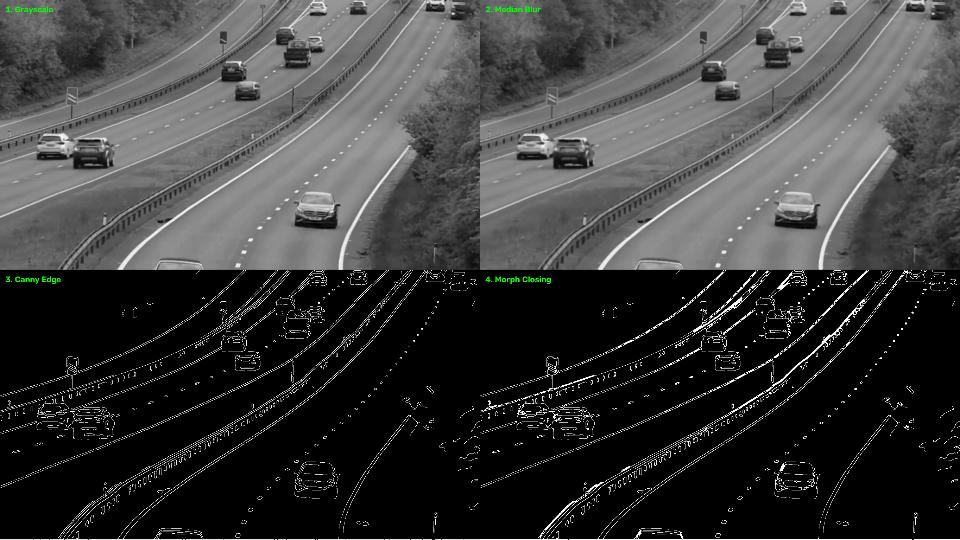

Pipeline execution stopped manually.


In [16]:
video_path = r"C:\Users\PC-LAB1\img_processing_lab\videos\british_highway_traffic.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    # Kernel for morphological closing
    kernel = np.ones((3, 3), np.uint8)

    # Set up inline display handle
    d = display.display(display.Image(data=b""), display_id=True)

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # ---------------------------------------------------------
            # PIPELINE EXECUTION
            # ---------------------------------------------------------

            # Step 1: Grayscale Conversion
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Step 2: Median Blur (ksize must be an odd integer, e.g., 5)
            median = cv2.medianBlur(gray, 5)

            # Step 3: Canny Edge Detection
            canny = cv2.Canny(median, 50, 150)

            # Step 4: Morphological Closing (Dilation -> Erosion)
            closed = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel)

            # ---------------------------------------------------------
            # VISUALIZATION PREPARATION
            # ---------------------------------------------------------

            # Convert 1-channel outputs to 3-channel BGR for side-by-side display
            gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            median_bgr = cv2.cvtColor(median, cv2.COLOR_GRAY2BGR)
            canny_bgr = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
            closed_bgr = cv2.cvtColor(closed, cv2.COLOR_GRAY2BGR)

            # Overlay step titles on each stage
            font = cv2.FONT_HERSHEY_SIMPLEX
            cv2.putText(
                gray_bgr, "1. Grayscale", (15, 35), font, 0.8, (0, 255, 0), 2
            )
            cv2.putText(
                median_bgr, "2. Median Blur", (15, 35), font, 0.8, (0, 255, 0), 2
            )
            cv2.putText(
                canny_bgr, "3. Canny Edge", (15, 35), font, 0.8, (0, 255, 0), 2
            )
            cv2.putText(
                closed_bgr, "4. Morph Closing", (15, 35), font, 0.8, (0, 255, 0), 2
            )

            # Combine the 4 stages into a 2x2 grid
            top_row = np.hstack((gray_bgr, median_bgr))
            bottom_row = np.hstack((canny_bgr, closed_bgr))
            pipeline_grid = np.vstack((top_row, bottom_row))

            # Resize the final grid layout for crisp inline playback
            resized_grid = cv2.resize(pipeline_grid, (960, 540))

            # Encode and stream to Jupyter cell
            rgb_grid = cv2.cvtColor(resized_grid, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_grid)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG")

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Pipeline execution stopped manually.")

cap.release()

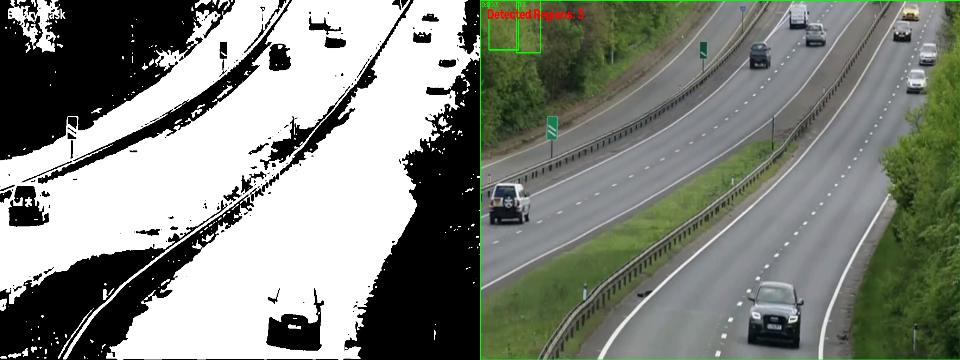

Region detection stopped manually.


In [17]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    # Set up IPython Display handle for cell streaming
    d = display.display(display.Image(data=b""), display_id=True)
    
    # Minimum surface area threshold (in pixels) to ignore noise
    MIN_CONTOUR_AREA = 500

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # ---------------------------------------------------------
            # 1. CREATE BINARY / EDGE IMAGE
            # ---------------------------------------------------------
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)
            
            # Otsu's thresholding creates clean binary mask for region isolation
            _, binary_mask = cv2.threshold(
                blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )

            # ---------------------------------------------------------
            # 2. FIND CONTOURS
            # ---------------------------------------------------------
            # cv2.findContours modifies source image; work on copy or mask
            contours, _ = cv2.findContours(
                binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            # ---------------------------------------------------------
            # 3. FILTER BY AREA & 4. DRAW BOUNDING RECTANGLES
            # ---------------------------------------------------------
            valid_regions_count = 0
            output_frame = frame.copy()

            for cnt in contours:
                # Calculate pixel area of current shape
                area = cv2.contourArea(cnt)

                # Filter out tiny noise contours
                if area >= MIN_CONTOUR_AREA:
                    valid_regions_count += 1

                    # Get bounding box coordinates
                    x, y, w, h = cv2.boundingRect(cnt)

                    # Draw green rectangle around region
                    cv2.rectangle(
                        output_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                    )

                    # Label individual region index and area
                    cv2.putText(
                        output_frame,
                        f"ID:{valid_regions_count}",
                        (x, max(y - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (0, 255, 0),
                        1,
                    )

            # ---------------------------------------------------------
            # 5. DISPLAY TOTAL DETECTED REGIONS
            # ---------------------------------------------------------
            cv2.putText(
                output_frame,
                f"Detected Regions: {valid_regions_count}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 0, 255),
                2,
            )

            # --- DISPLAY PREPARATION (Original Binary vs. Tracked Output) ---
            binary_bgr = cv2.cvtColor(binary_mask, cv2.COLOR_GRAY2BGR)
            cv2.putText(
                binary_bgr, "Binary Mask", (20, 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2
            )

            # Stack horizontally (Binary Mask | Tracked Regions)
            combined_view = np.hstack((binary_bgr, output_frame))
            resized_view = cv2.resize(combined_view, (960, 360))

            # Encode and display frame
            rgb_view = cv2.cvtColor(resized_view, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_view)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG")

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Region detection stopped manually.")

cap.release()

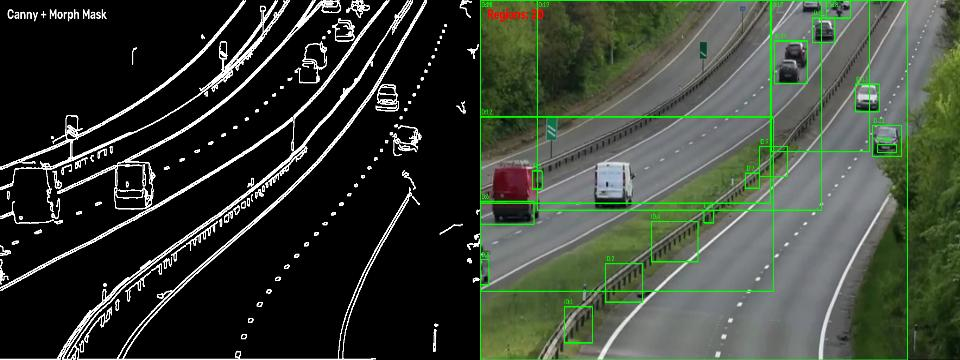

End of video stream.


In [19]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    d = display.display(display.Image(data=b""), display_id=True)

    # Kernel for dilation/closing (fills gaps in Canny edges)
    kernel = np.ones((3, 3), np.uint8)

    # Minimum contour area filter (in pixels)
    MIN_CONTOUR_AREA = 300

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # ---------------------------------------------------------
            # 1. EDGE-BASED PREPROCESSING PIPELINE
            # ---------------------------------------------------------
            # Step A: Grayscale
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            # Step B: Gaussian Blur to suppress high-frequency noise
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)

            # Step C: Canny Edge Detection
            canny = cv2.Canny(blurred, 50, 150)

            # Step D: Morphological Dilation / Closing
            # Connects broken edge segments so contours form closed loops
            edge_mask = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel)
            edge_mask = cv2.dilate(edge_mask, kernel, iterations=1)

            # ---------------------------------------------------------
            # 2. FIND CONTOURS ON EDGE MAP
            # ---------------------------------------------------------
            contours, _ = cv2.findContours(
                edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            # ---------------------------------------------------------
            # 3. FILTER BY AREA & 4. DRAW BOUNDING BOXES
            # ---------------------------------------------------------
            valid_regions_count = 0
            output_frame = frame.copy()

            for cnt in contours:
                area = cv2.contourArea(cnt)

                # Filter out small edge artifacts and noise
                if area >= MIN_CONTOUR_AREA:
                    valid_regions_count += 1

                    # Get bounding box coordinates
                    x, y, w, h = cv2.boundingRect(cnt)

                    # Draw green bounding rectangle
                    cv2.rectangle(
                        output_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                    )

                    # Draw index label
                    cv2.putText(
                        output_frame,
                        f"ID:{valid_regions_count}",
                        (x, max(y - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (0, 255, 0),
                        1,
                    )

            # ---------------------------------------------------------
            # 5. DISPLAY DETECTED REGION COUNT
            # ---------------------------------------------------------
            cv2.putText(
                output_frame,
                f"Regions: {valid_regions_count}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 0, 255),
                2,
            )

            # --- DISPLAY PREPARATION (Processed Edges vs. Detected Regions) ---
            edge_bgr = cv2.cvtColor(edge_mask, cv2.COLOR_GRAY2BGR)
            cv2.putText(
                edge_bgr,
                "Canny + Morph Mask",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (255, 255, 255),
                2,
            )

            # Stack horizontally (Edge Mask | Tracked Regions)
            combined_view = np.hstack((edge_bgr, output_frame))
            resized_view = cv2.resize(combined_view, (960, 360))

            # Encode and stream to cell output
            rgb_view = cv2.cvtColor(resized_view, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_view)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG")

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Region detection stopped manually.")

cap.release()

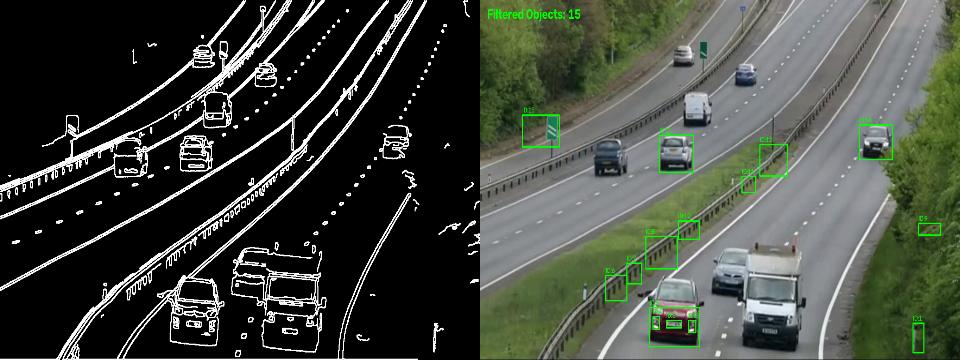

Processing interrupted.


In [23]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    d = display.display(display.Image(data=b""), display_id=True)
    kernel = np.ones((3, 3), np.uint8)

    # ---------------------------------------------------------
    # GEOMETRIC FILTER PARAMETERS
    # ---------------------------------------------------------
    MIN_AREA = 300       # Ignores small noise points
    MAX_AREA = 15000     # Rejects huge road-spanning regions
    MAX_WIDTH = 250      # Rejects horizontal lane/guardrail spans
    MAX_HEIGHT = 250     # Rejects long vertical edge lines
    MIN_ASPECT = 0.25    # Rejects extremely thin horizontal/vertical lines
    MAX_ASPECT = 3.5

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # 1. Edge Detection Pipeline
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blurred = cv2.GaussianBlur(gray, (5, 5), 0)
            canny = cv2.Canny(blurred, 50, 150)
            
            # Close edge gaps and slightly dilate
            edge_mask = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel)
            edge_mask = cv2.dilate(edge_mask, kernel, iterations=1)

            # 2. Find Contours
            contours, _ = cv2.findContours(
                edge_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            output_frame = frame.copy()
            valid_regions_count = 0

            # 3. Geometric Filtering
            for cnt in contours:
                area = cv2.contourArea(cnt)
                x, y, w, h = cv2.boundingRect(cnt)
                aspect_ratio = float(w) / h if h > 0 else 0

                # Apply geometric checks
                if (MIN_AREA <= area <= MAX_AREA) and (w <= MAX_WIDTH) and (h <= MAX_HEIGHT):
                    if MIN_ASPECT <= aspect_ratio <= MAX_ASPECT:
                        valid_regions_count += 1

                        # Draw filtered bounding box
                        cv2.rectangle(
                            output_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                        )
                        cv2.putText(
                            output_frame,
                            f"ID:{valid_regions_count}",
                            (x, max(y - 5, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5,
                            (0, 255, 0),
                            1,
                        )

            # Display region count
            cv2.putText(
                output_frame,
                f"Filtered Objects: {valid_regions_count}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.0,
                (0, 255, 0),
                2,
            )

            # Render view
            edge_bgr = cv2.cvtColor(edge_mask, cv2.COLOR_GRAY2BGR)
            combined_view = np.hstack((edge_bgr, output_frame))
            resized_view = cv2.resize(combined_view, (960, 360))

            rgb_view = cv2.cvtColor(resized_view, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_view)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG")

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Processing interrupted.")

cap.release()

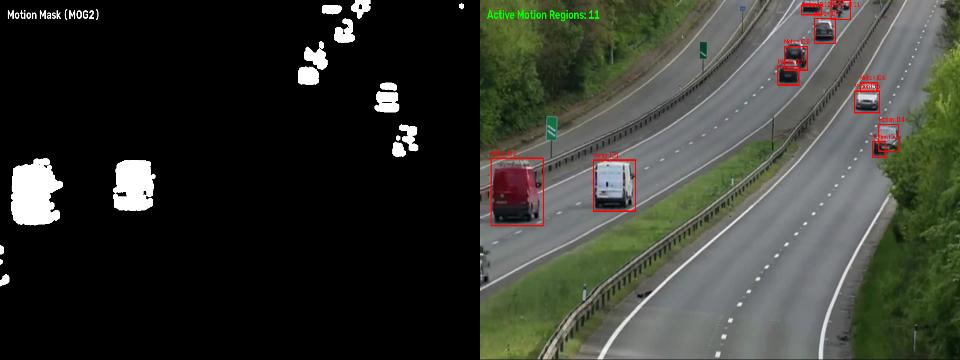

End of video stream.


In [24]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    # Set up inline display
    d = display.display(display.Image(data=b""), display_id=True)

    # 1. Initialize MOG2 Subtractor (Alternative: cv2.createBackgroundSubtractorKNN())
    backSub = cv2.createBackgroundSubtractorMOG2(
        history=500, varThreshold=50, detectShadows=True
    )

    # Structuring element for morphological cleanup
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    MIN_CONTOUR_AREA = 500  # Ignore small motion noise

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # ---------------------------------------------------------
            # STEP 1 & 2: BACKGROUND SUBTRACTION & THRESHOLDING
            # ---------------------------------------------------------
            # Generate raw foreground mask (0=bg, 255=fg, 127=shadow)
            fg_mask = backSub.apply(frame)

            # Strip shadows (gray pixels = 127) to isolate solid movement
            _, binary_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

            # ---------------------------------------------------------
            # STEP 3: MORPHOLOGICAL CLEANUP
            # ---------------------------------------------------------
            # Opening removes small speckle noise; Dilation bridges inner gaps
            clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
            clean_mask = cv2.dilate(clean_mask, kernel, iterations=2)

            # ---------------------------------------------------------
            # STEP 4 & 5: CONTOURS & BOUNDING BOXES
            # ---------------------------------------------------------
            contours, _ = cv2.findContours(
                clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            output_frame = frame.copy()
            motion_count = 0

            for cnt in contours:
                area = cv2.contourArea(cnt)

                if area >= MIN_CONTOUR_AREA:
                    motion_count += 1

                    # Extract box dimensions
                    x, y, w, h = cv2.boundingRect(cnt)

                    # Draw red bounding box around moving objects
                    cv2.rectangle(
                        output_frame, (x, y), (x + w, y + h), (0, 0, 255), 2
                    )

                    cv2.putText(
                        output_frame,
                        f"Motion ID:{motion_count}",
                        (x, max(y - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.5,
                        (0, 0, 255),
                        1,
                    )

            # Display active motion count
            cv2.putText(
                output_frame,
                f"Active Motion Regions: {motion_count}",
                (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (0, 255, 0),
                2,
            )

            # --- PREPARE COMBINED DISPLAY (Motion Mask | Motion Tracking) ---
            mask_bgr = cv2.cvtColor(clean_mask, cv2.COLOR_GRAY2BGR)
            cv2.putText(
                mask_bgr, "Motion Mask (MOG2)", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2
            )

            combined_view = np.hstack((mask_bgr, output_frame))
            resized_view = cv2.resize(combined_view, (960, 360))

            rgb_view = cv2.cvtColor(resized_view, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_view)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG")

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Motion detection stopped manually.")

cap.release()

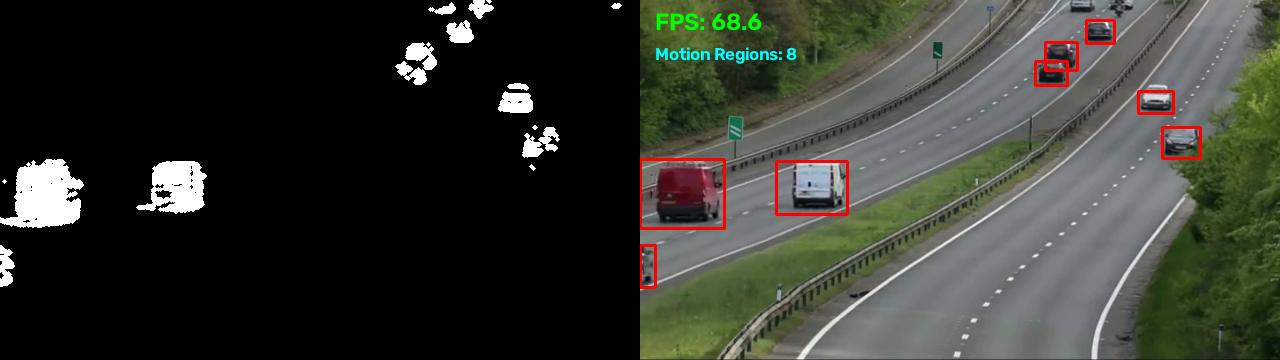

End of video stream.


In [28]:
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    d = display.display(display.Image(data=b""), display_id=True)

    # 1. Faster Background Subtractor config
    backSub = cv2.createBackgroundSubtractorMOG2(
        history=200, varThreshold=50, detectShadows=False  # Turning off shadows boosts speed
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    MIN_CONTOUR_AREA = 300

    # Variables for FPS calculation
    prev_frame_time = time.time()
    fps = 0.0

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                print("End of video stream.")
                break

            # --- OPTIMIZATION: Resize frame early to boost pipeline speed ---
            # Processing at 640px width reduces pixel computations by >50%
            process_width = 640
            h, w = frame.shape[:2]
            aspect = h / w
            process_height = int(process_width * aspect)
            frame_resized = cv2.resize(frame, (process_width, process_height))

            # ---------------------------------------------------------
            # MOTION PIPELINE
            # ---------------------------------------------------------
            fg_mask = backSub.apply(frame_resized)
            _, binary_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

            clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
            clean_mask = cv2.dilate(clean_mask, kernel, iterations=1)

            contours, _ = cv2.findContours(
                clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            output_frame = frame_resized.copy()
            motion_count = 0

            for cnt in contours:
                if cv2.contourArea(cnt) >= MIN_CONTOUR_AREA:
                    motion_count += 1
                    x, y, w_box, h_box = cv2.boundingRect(cnt)
                    cv2.rectangle(
                        output_frame, (x, y), (x + w_box, y + h_box), (0, 0, 255), 2
                    )

            # ---------------------------------------------------------
            # FPS CALCULATION
            # ---------------------------------------------------------
            current_frame_time = time.time()
            time_diff = current_frame_time - prev_frame_time
            if time_diff > 0:
                fps = 1.0 / time_diff
            prev_frame_time = current_frame_time

            # Overlay FPS counter & Motion count
            cv2.putText(
                output_frame,
                f"FPS: {fps:.1f}",
                (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2,
            )
            cv2.putText(
                output_frame,
                f"Motion Regions: {motion_count}",
                (15, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 0),
                2,
            )

            # --- PREPARE COMBINED DISPLAY ---
            mask_bgr = cv2.cvtColor(clean_mask, cv2.COLOR_GRAY2BGR)
            combined_view = np.hstack((mask_bgr, output_frame))

            # Encode and stream
            rgb_view = cv2.cvtColor(combined_view, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_view)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG", quality=75)  # Quality 75 speeds up JPEG encoding

            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("Motion detection stopped manually.")

cap.release()

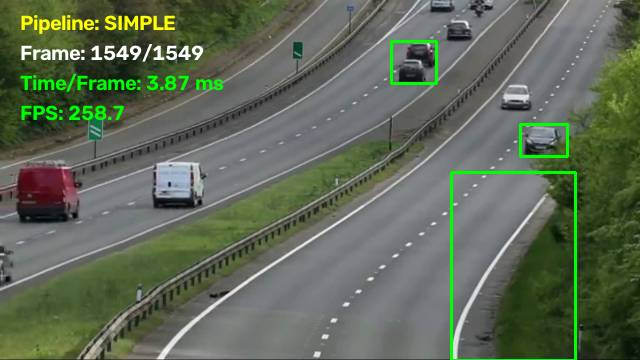


           PIPELINE BENCHMARK REPORT              
Pipeline Strategy     : SIMPLE
Total Frames Processed: 1549 / 1549
Video Native FPS      : 25.00
Total Runtime         : 15.71 seconds
--------------------------------------------------
Average Frame Time    : 2.70 ms
Min Frame Time        : 1.69 ms
Max Frame Time        : 12.39 ms
Average Processing FPS: 370.71 FPS



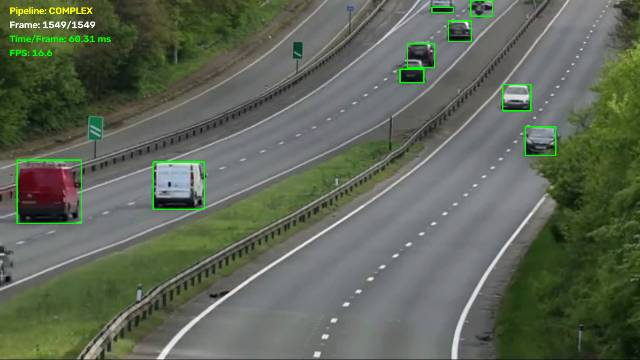


           PIPELINE BENCHMARK REPORT              
Pipeline Strategy     : COMPLEX
Total Frames Processed: 1549 / 1549
Video Native FPS      : 25.00
Total Runtime         : 107.61 seconds
--------------------------------------------------
Average Frame Time    : 62.14 ms
Min Frame Time        : 54.01 ms
Max Frame Time        : 155.39 ms
Average Processing FPS: 16.09 FPS



In [32]:
def run_full_video_benchmark(pipeline_type="simple"):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video path '{video_path}'")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_fps = cap.get(cv2.CAP_PROP_FPS)

    d = display.display(display.Image(data=b""), display_id=True)

    # Pre-allocate resources for pipelines
    backSub = cv2.createBackgroundSubtractorMOG2(
        history=200, varThreshold=50, detectShadows=True
    )
    kernel_small = np.ones((3, 3), np.uint8)
    kernel_large = np.ones((7, 7), np.uint8)

    frame_times = []
    frame_index = 0
    start_total_time = time.perf_counter()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break  # Video completed

            frame_index += 1
            t_start = time.perf_counter()

            # ---------------------------------------------------------
            # PIPELINE SELECTION
            # ---------------------------------------------------------
            if pipeline_type == "simple":
                # SIMPLE: Downscale -> Grayscale -> Blur -> Canny -> Contours + Bounding Boxes
                resized = cv2.resize(frame, (640, 360))
                gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
                blurred = cv2.GaussianBlur(gray, (5, 5), 0)
                canny = cv2.Canny(blurred, 50, 150)
                
                # Morphological close to bridge edge gaps for cleaner contours
                closed_edges = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel_small)
                
                # Contour detection on edges
                contours, _ = cv2.findContours(
                    closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )

                display_frame = resized.copy()
                for cnt in contours:
                    area = cv2.contourArea(cnt)
                    x, y, w, h = cv2.boundingRect(cnt)
                    aspect_ratio = float(w) / h if h > 0 else 0

                    # Filter out small noise and road-spanning lines
                    if (300 <= area <= 15000) and (w <= 250) and (h <= 250):
                        if 0.25 <= aspect_ratio <= 3.5:
                            cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

            else:
                # COMPLEX: Full Res MOG2 -> Shadow Strip -> Median -> Contours + Bounding Boxes
                fg_mask = backSub.apply(frame)
                _, binary = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
                median = cv2.medianBlur(binary, 9)
                clean = cv2.morphologyEx(
                    median, cv2.MORPH_CLOSE, kernel_large, iterations=2
                )
                contours, _ = cv2.findContours(
                    clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
                )

                display_frame = frame.copy()
                for cnt in contours:
                    if cv2.contourArea(cnt) > 300:
                        x, y, w, h = cv2.boundingRect(cnt)
                        cv2.rectangle(
                            display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                        )

            # ---------------------------------------------------------
            # TIMING & OVERLAY METRICS
            # ---------------------------------------------------------
            t_end = time.perf_counter()
            elapsed_time_ms = (t_end - t_start) * 1000.0
            frame_times.append(elapsed_time_ms)
            current_fps = (
                1000.0 / elapsed_time_ms if elapsed_time_ms > 0 else 0.0
            )

            # Draw HUD metrics on image
            cv2.putText(
                display_frame,
                f"Pipeline: {pipeline_type.upper()}",
                (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 255),
                2,
            )
            cv2.putText(
                display_frame,
                f"Frame: {frame_index}/{total_frames}",
                (20, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2,
            )
            cv2.putText(
                display_frame,
                f"Time/Frame: {elapsed_time_ms:.2f} ms",
                (20, 90),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2,
            )
            cv2.putText(
                display_frame,
                f"FPS: {current_fps:.1f}",
                (20, 120),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2,
            )

            # Render to Notebook cell
            rgb_frame = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(cv2.resize(rgb_frame, (640, 360)))
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG", quality=70)
            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("\nBenchmark manually stopped by user.")

    cap.release()

    total_execution_time = time.perf_counter() - start_total_time
    avg_time_ms = np.mean(frame_times) if frame_times else 0
    min_time_ms = np.min(frame_times) if frame_times else 0
    max_time_ms = np.max(frame_times) if frame_times else 0
    avg_fps = 1000.0 / avg_time_ms if avg_time_ms > 0 else 0

    # ---------------------------------------------------------
    # PRINTABLE COPYABLE LOG SUMMARY
    # ---------------------------------------------------------
    log_summary = f"""
==================================================
           PIPELINE BENCHMARK REPORT              
==================================================
Pipeline Strategy     : {pipeline_type.upper()}
Total Frames Processed: {frame_index} / {total_frames}
Video Native FPS      : {video_fps:.2f}
Total Runtime         : {total_execution_time:.2f} seconds
--------------------------------------------------
Average Frame Time    : {avg_time_ms:.2f} ms
Min Frame Time        : {min_time_ms:.2f} ms
Max Frame Time        : {max_time_ms:.2f} ms
Average Processing FPS: {avg_fps:.2f} FPS
==================================================
"""
    print(log_summary)
    return log_summary


# Run simple pipeline across full video (Edge + Contours + Geometric Bounding Boxes)
simple_log = run_full_video_benchmark("simple")

# Run complex pipeline across full video (MOG2 Motion + Median Blur + Shadow Strip)
complex_log = run_full_video_benchmark("complex")

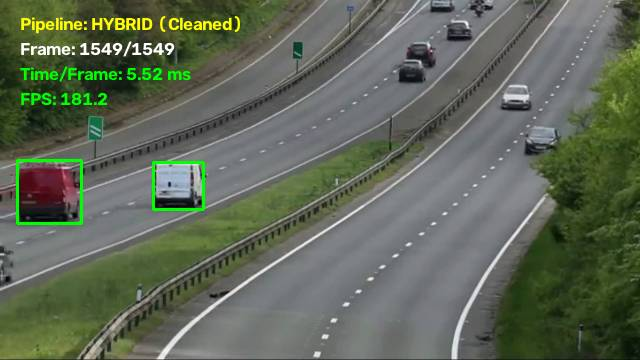


           PIPELINE BENCHMARK REPORT              
Pipeline Strategy     : HYBRID (Cleaned)
Total Frames Processed: 1549 / 1549
Video Native FPS      : 25.00
Total Runtime         : 22.18 seconds
--------------------------------------------------
Average Frame Time    : 6.32 ms
Min Frame Time        : 4.06 ms
Max Frame Time        : 13.63 ms
Average Processing FPS: 158.15 FPS



In [41]:
def run_hybrid_pipeline():
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video path '{video_path}'")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_fps = cap.get(cv2.CAP_PROP_FPS)

    d = display.display(display.Image(data=b""), display_id=True)

    # 1. Higher varThreshold (50) ignores subtle camera shakes and lighting shifts
    backSub_fast = cv2.createBackgroundSubtractorMOG2(
        history=300, varThreshold=50, detectShadows=True
    )

    # Structuring kernels
    kernel_small = np.ones((3, 3), np.uint8)
    kernel_medium = np.ones((5, 5), np.uint8)

    frame_times = []
    frame_index = 0
    start_total_time = time.perf_counter()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_index += 1
            t_start = time.perf_counter()

            # Step A: Early Downscaling
            resized = cv2.resize(frame, (640, 360))

            # Step B: Background Subtraction
            fg_mask = backSub_fast.apply(resized)

            # Step C: Strict Thresholding (Strips gray shadows @ 127)
            _, binary = cv2.threshold(fg_mask, 250, 255, cv2.THRESH_BINARY)

            # Step D: Fast 5x5 Median Blur (Erases salt-and-pepper noise spikes completely)
            median = cv2.medianBlur(binary, 5)

            # Step E: Morphological Close (Solidifies vehicle bodies) then Open (Removes stray specks)
            clean = cv2.morphologyEx(median, cv2.MORPH_CLOSE, kernel_medium)
            clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel_small)

            # Step F: Contour-based Bounding Boxes
            contours, _ = cv2.findContours(
                clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            display_frame = resized.copy()

            # Global Motion Spike Guard: Discard frame processing during massive camera shakes (>30 objects)
            if len(contours) < 30:
                for cnt in contours:
                    area = cv2.contourArea(cnt)
                    x, y, w, h = cv2.boundingRect(cnt)
                    aspect_ratio = float(w) / h if h > 0 else 0

                    # 2. Strict Geometric Filter: Eliminates non-vehicle noise, road strips, and edge specs
                    if (250 <= area <= 12000) and (20 <= w <= 220) and (20 <= h <= 220):
                        if 0.35 <= aspect_ratio <= 2.8:
                            cv2.rectangle(
                                display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                            )

            # ---------------------------------------------------------
            # METRICS & DISPLAY OVERLAY
            # ---------------------------------------------------------
            t_end = time.perf_counter()
            elapsed_time_ms = (t_end - t_start) * 1000.0
            frame_times.append(elapsed_time_ms)
            current_fps = (
                1000.0 / elapsed_time_ms if elapsed_time_ms > 0 else 0.0
            )

            cv2.putText(
                display_frame,
                "Pipeline: HYBRID (Cleaned)",
                (20, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2,
            )
            cv2.putText(
                display_frame,
                f"Frame: {frame_index}/{total_frames}",
                (20, 55),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 255, 255),
                2,
            )
            cv2.putText(
                display_frame,
                f"Time/Frame: {elapsed_time_ms:.2f} ms",
                (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2,
            )
            cv2.putText(
                display_frame,
                f"FPS: {current_fps:.1f}",
                (20, 105),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2,
            )

            rgb_frame = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb_frame)
            buf = io.BytesIO()
            pil_img.save(buf, format="JPEG", quality=70)
            d.update(display.Image(data=buf.getvalue()))

    except KeyboardInterrupt:
        print("\nBenchmark manually stopped.")

    cap.release()

    total_execution_time = time.perf_counter() - start_total_time
    avg_time_ms = np.mean(frame_times) if frame_times else 0
    min_time_ms = np.min(frame_times) if frame_times else 0
    max_time_ms = np.max(frame_times) if frame_times else 0
    avg_fps = 1000.0 / avg_time_ms if avg_time_ms > 0 else 0

    log_summary = f"""
==================================================
           PIPELINE BENCHMARK REPORT              
==================================================
Pipeline Strategy     : HYBRID (Cleaned)
Total Frames Processed: {frame_index} / {total_frames}
Video Native FPS      : {video_fps:.2f}
Total Runtime         : {total_execution_time:.2f} seconds
--------------------------------------------------
Average Frame Time    : {avg_time_ms:.2f} ms
Min Frame Time        : {min_time_ms:.2f} ms
Max Frame Time        : {max_time_ms:.2f} ms
Average Processing FPS: {avg_fps:.2f} FPS
==================================================
"""
    print(log_summary)
    return log_summary


# Run the Cleaned Hybrid Benchmark
hybrid_log = run_hybrid_pipeline()

In [44]:
output_path = r"C:\Users\PC-LAB1\img_processing_lab\output\british_hybrid_result.mp4"  # Saved output path


def process_and_save_video():
    # 1. Initialize Video Capture
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open input video '{video_path}'")
        return

    # Extract Video Properties to match input specifications
    video_fps = cap.get(cv2.CAP_PROP_FPS)

    # Output dimensions matching our early downscale resolution (640x360)
    frame_width = 640
    frame_height = 360

    # 2. Select Video Codec and Initialize VideoWriter
    # 'mp4v' is a standard cross-platform MP4 FOURCC codec
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(
        output_path, fourcc, video_fps, (frame_width, frame_height)
    )

    # 3. Setup MOG2 Subtractor & Morphological Kernels
    backSub_fast = cv2.createBackgroundSubtractorMOG2(
        history=300, varThreshold=50, detectShadows=True
    )
    kernel_small = np.ones((3, 3), np.uint8)
    kernel_medium = np.ones((5, 5), np.uint8)

    frame_index = 0
    start_time = time.perf_counter()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break  # Complete

            frame_index += 1

            # --- HYBRID PIPELINE PROCESSING ---
            # A. Resize to output dimensions
            resized = cv2.resize(frame, (frame_width, frame_height))

            # B. Background Subtraction
            fg_mask = backSub_fast.apply(resized)

            # C. Thresholding (remove shadows)
            _, binary = cv2.threshold(fg_mask, 250, 255, cv2.THRESH_BINARY)

            # D. Fast Median Blur
            median = cv2.medianBlur(binary, 5)

            # E. Morphological Clean
            clean = cv2.morphologyEx(median, cv2.MORPH_CLOSE, kernel_medium)
            clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel_small)

            # F. Contour Detection & Bounding Box Filtering
            contours, _ = cv2.findContours(
                clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            display_frame = resized.copy()

            if len(contours) < 30:  # Spike guard
                for cnt in contours:
                    area = cv2.contourArea(cnt)
                    x, y, w, h = cv2.boundingRect(cnt)
                    aspect_ratio = float(w) / h if h > 0 else 0

                    if (250 <= area <= 12000) and (20 <= w <= 220) and (20 <= h <= 220):
                        if 0.35 <= aspect_ratio <= 2.8:
                            cv2.rectangle(
                                display_frame,
                                (x, y),
                                (x + w, y + h),
                                (0, 255, 0),
                                2,
                            )

            # --- WRITE FRAME TO OUTPUT FILE ---
            out.write(display_frame)

    except KeyboardInterrupt:
        print("\nProcessing interrupted manually.")

    # 4. Correct Resource Cleanup
    cap.release()
    out.release()
    cv2.destroyAllWindows()

    total_time = time.perf_counter() - start_time
    print(
        f"\nSUCCESS: Processed {frame_index} frames in {total_time:.2f}s."
    )
    print(f"Output video successfully saved to: '{output_path}'")


# Execute the script
process_and_save_video()


SUCCESS: Processed 1549 frames in 13.70s.
Output video successfully saved to: 'C:\Users\PC-LAB1\img_processing_lab\output\british_hybrid_result.mp4'


In [45]:
output_path = r"C:\Users\PC-LAB1\img_processing_lab\output\british_complex_result.mp4"

def process_and_save_complex_pipeline():
    # 1. Initialize Video Capture
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open input video '{video_path}'")
        return

    # Extract Video Properties to match full original specifications
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # 2. Select Video Codec and Initialize VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(
        output_path, fourcc, video_fps, (frame_width, frame_height)
    )

    # 3. Setup Complex Pipeline Components (Full-Res MOG2 + Shadows)
    backSub = cv2.createBackgroundSubtractorMOG2(
        history=200, varThreshold=50, detectShadows=True
    )
    kernel_large = np.ones((7, 7), np.uint8)

    frame_index = 0
    start_time = time.perf_counter()

    try:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break  # Video processing complete

            frame_index += 1

            # ---------------------------------------------------------
            # COMPLEX PIPELINE PROCESSING (FULL RESOLUTION)
            # ---------------------------------------------------------
            # Step A: Apply MOG2 Background Subtraction with Shadow Detection
            fg_mask = backSub.apply(frame)

            # Step B: Strip shadow pixels (values < 200) to isolate foreground
            _, binary = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

            # Step C: Heavy 9x9 Median Filter for noise elimination
            median = cv2.medianBlur(binary, 9)

            # Step D: Iterative Morphological Closing (7x7 Kernel, 2 Iterations)
            clean = cv2.morphologyEx(
                median, cv2.MORPH_CLOSE, kernel_large, iterations=2
            )

            # Step E: Find Contours & Draw Bounding Boxes on Native Resolution
            contours, _ = cv2.findContours(
                clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )

            display_frame = frame.copy()
            for cnt in contours:
                # Minimum area scaled for full resolution (e.g., 1080p / 720p)
                if cv2.contourArea(cnt) > 500:
                    x, y, w, h = cv2.boundingRect(cnt)
                    cv2.rectangle(
                        display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2
                    )

            # ---------------------------------------------------------
            # WRITE FRAME TO DISK
            # ---------------------------------------------------------
            out.write(display_frame)

    except KeyboardInterrupt:
        print("\nProcessing interrupted manually.")

    # 4. Safe Resource Cleanup
    cap.release()
    out.release()
    cv2.destroyAllWindows()

    total_time = time.perf_counter() - start_time
    avg_fps = frame_index / total_time if total_time > 0 else 0

    print(f"\n==================================================")
    print(f"COMPLEX PIPELINE EXPORT COMPLETE")
    print(f"==================================================")
    print(f"Total Frames Processed : {frame_index}")
    print(f"Output Video Resolution: {frame_width}x{frame_height}")
    print(f"Processing Speed       : {avg_fps:.2f} FPS ({total_time:.2f}s total)")
    print(f"File Saved To          : {output_path}")
    print(f"==================================================")


# Execute the script
process_and_save_complex_pipeline()


COMPLEX PIPELINE EXPORT COMPLETE
Total Frames Processed : 1549
Output Video Resolution: 1364x768
Processing Speed       : 13.82 FPS (112.11s total)
File Saved To          : C:\Users\PC-LAB1\img_processing_lab\output\british_complex_result.mp4
